In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import chi2_contingency, pointbiserialr, mannwhitneyu, pearsonr

import pickle

In [11]:
data_path = '/work/model_myocardial_infarction/dataset/processed_data.csv'
df = pd.read_csv(data_path)

In [13]:
df.head()

,PHYSHLTH,MENTHLTH,POORHLTH,PERSDOC3,MEDCOST1,CHECKUP1,CVDSTRK3,CHCSCNC1,CHCOCNC1,CHCCOPD3,...,_EDUCAG,_INCOMG1,_SMOKER3,_CURECI3,_LCSYSMK,_LCSYQTS,DRNKANY6,_RFBING6,_DRNKWK3,_RFDRHV9
0,2.0,0.0,0.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,...,2.0,NaN,4.0,1.0,NaN,NaN,0.0,1.0,5.397605e-79,1.0
1,0.0,0.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,4.0,NaN,3.0,1.0,2.0,53.0,0.0,1.0,5.397605e-79,1.0
2,30.0,0.0,1.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,...,3.0,NaN,1.0,1.0,45.0,NaN,1.0,0.0,1.400000e+03,1.0
3,0.0,0.0,NaN,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,4.0,4.0,4.0,1.0,NaN,NaN,0.0,1.0,5.397605e-79,1.0
4,0.0,0.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,3.0,2.0,4.0,1.0,NaN,NaN,0.0,1.0,5.397605e-79,1.0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457670 entries, 0 to 457669
Data columns (total 73 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   PHYSHLTH  446603 non-null  float64
 1   MENTHLTH  449514 non-null  float64
 2   POORHLTH  262642 non-null  float64
 3   PERSDOC3  453057 non-null  float64
 4   MEDCOST1  455997 non-null  float64
 5   CHECKUP1  449553 non-null  float64
 6   CVDSTRK3  456218 non-null  float64
 7   CHCSCNC1  454645 non-null  float64
 8   CHCOCNC1  455224 non-null  float64
 9   CHCCOPD3  455496 non-null  float64
 10  ADDEPEV3  455006 non-null  float64
 11  CHCKDNY2  455691 non-null  float64
 12  HAVARTH4  455097 non-null  float64
 13  DIABETE4  456636 non-null  float64
 14  MARITAL   453448 non-null  float64
 15  VETERAN3  455094 non-null  float64
 16  PREGNANT  80899 non-null   float64
 17  DEAF      440567 non-null  float64
 18  BLIND     439676 non-null  float64
 19  DECIDE    437158 non-null  float64
 20  DIFF

In [17]:
df.describe()

,PHYSHLTH,MENTHLTH,POORHLTH,PERSDOC3,MEDCOST1,CHECKUP1,CVDSTRK3,CHCSCNC1,CHCOCNC1,CHCCOPD3,...,_EDUCAG,_INCOMG1,_SMOKER3,_CURECI3,_LCSYSMK,_LCSYQTS,DRNKANY6,_RFBING6,_DRNKWK3,_RFDRHV9
count,446603.000000,449514.000000,262642.000000,453057.000000,455997.000000,449553.000000,456218.000000,454645.000000,455224.000000,455496.000000,...,455307.000000,340553.000000,425648.000000,424919.000000,1.517000e+05,1.204210e+05,413893.000000,410254.000000,4.109720e+05,410972.000000
mean,4.608337,4.414697,5.448531,1.217306,0.095095,1.306527,0.045288,0.086014,0.120716,0.081057,...,3.046944,4.311866,3.419934,0.942328,2.446048e+01,2.193860e+01,0.508904,0.865973,2.791986e+02,0.941213
std,8.929644,8.360289,9.113203,0.646345,0.293346,0.744071,0.207934,0.280386,0.325798,0.272922,...,0.954733,1.505638,0.880964,0.233123,1.646916e+01,1.747750e+01,0.499921,0.340681,8.957519e+02,0.235227
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,5.397605e-79,5.397605e-79,0.000000,0.000000,5.397605e-79,0.000000
25%,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,3.000000,3.000000,1.000000,1.000000e+01,6.000000e+00,0.000000,1.000000,5.397605e-79,1.000000
50%,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,3.000000,5.000000,4.000000,1.000000,2.200000e+01,1.900000e+01,1.000000,1.000000,2.300000e+01,1.000000
75%,4.000000,5.000000,6.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,5.000000,4.000000,1.000000,3.700000e+01,3.600000e+01,1.000000,1.000000,2.100000e+02,1.000000
max,30.000000,30.000000,30.000000,2.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,...,4.000000,6.000000,4.000000,1.000000,9.400000e+01,8.300000e+01,1.000000,1.000000,5.320000e+04,1.000000


In [19]:
# Parameters
path = '/work/model_myocardial_infarction/dataset/processed_data.csv'
df = pd.read_csv(path)
TARGET = '_MICHD'
CHUNK  = 9
P_THRESHOLD = 0.05
CV_THRESHOLD = 0.09 #binary
CORR_THRESHOLD = 0.1 #continuous

In [21]:
binary_cols = [c for c in df.columns
               if c != TARGET and df[c].nunique() == 2]
continuous_cols = [c for c in df.select_dtypes("number").columns
                   if c != TARGET and df[c].nunique() >= 3]

In [23]:
print(f"Number of all columns: {len(df.columns)}")
print(f"Number of binary feature columns: {len(binary_cols)}")
print(f"Number of continuous feature columns: {len(continuous_cols)}")

Number of all columns: 73
Number of binary feature columns: 41
Number of continuous feature columns: 31


In [25]:
# Helper Functions
def cramers_v(x, y):
    ct   = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n    = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

def plot_chunks(cols, plot_fn, suptitle_fmt, cols_per_row=3):
    chunks = [cols[i:i+CHUNK] for i in range(0, len(cols), CHUNK)]
    for batch, chunk in enumerate(chunks, 1):
        n_cols = min(cols_per_row, len(chunk))
        n_rows = (len(chunk) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(n_cols * 4.5, n_rows * 3.5))
        axes = np.array(axes).flatten()
        for j, col in enumerate(chunk):
            plot_fn(col, j, axes[j])
        for k in range(len(chunk), len(axes)):
            axes[k].set_visible(False)
        fig.suptitle(suptitle_fmt.format(batch, len(chunks)),
                     y=1.01, fontsize=12)
        plt.tight_layout(); plt.show()

### Significance Testing & Effect Size Estimation on Binary Variables vs\. \_MICHD

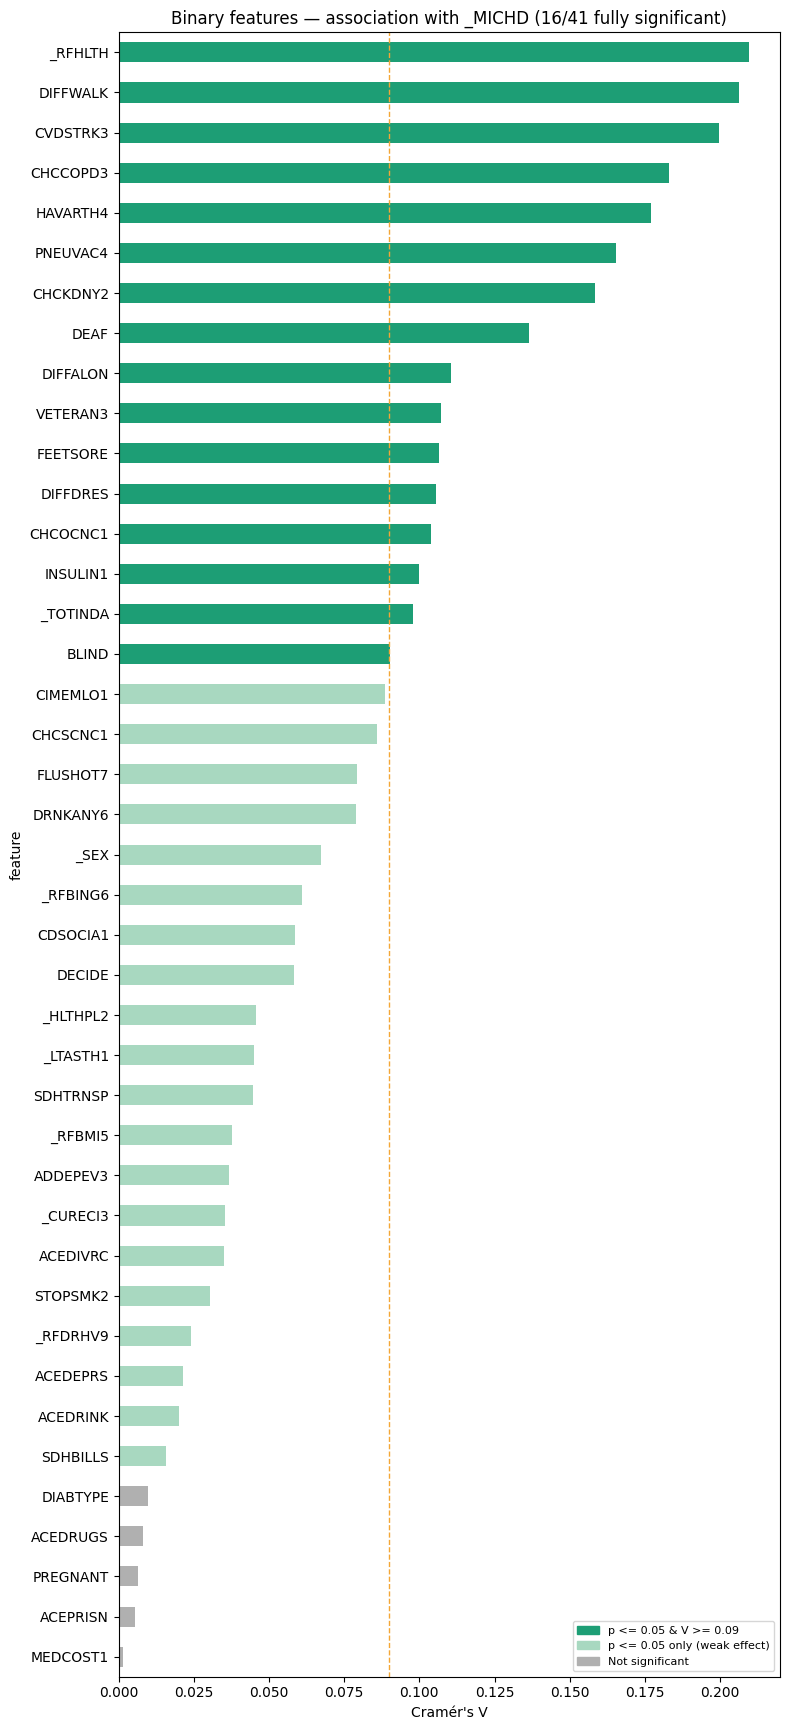

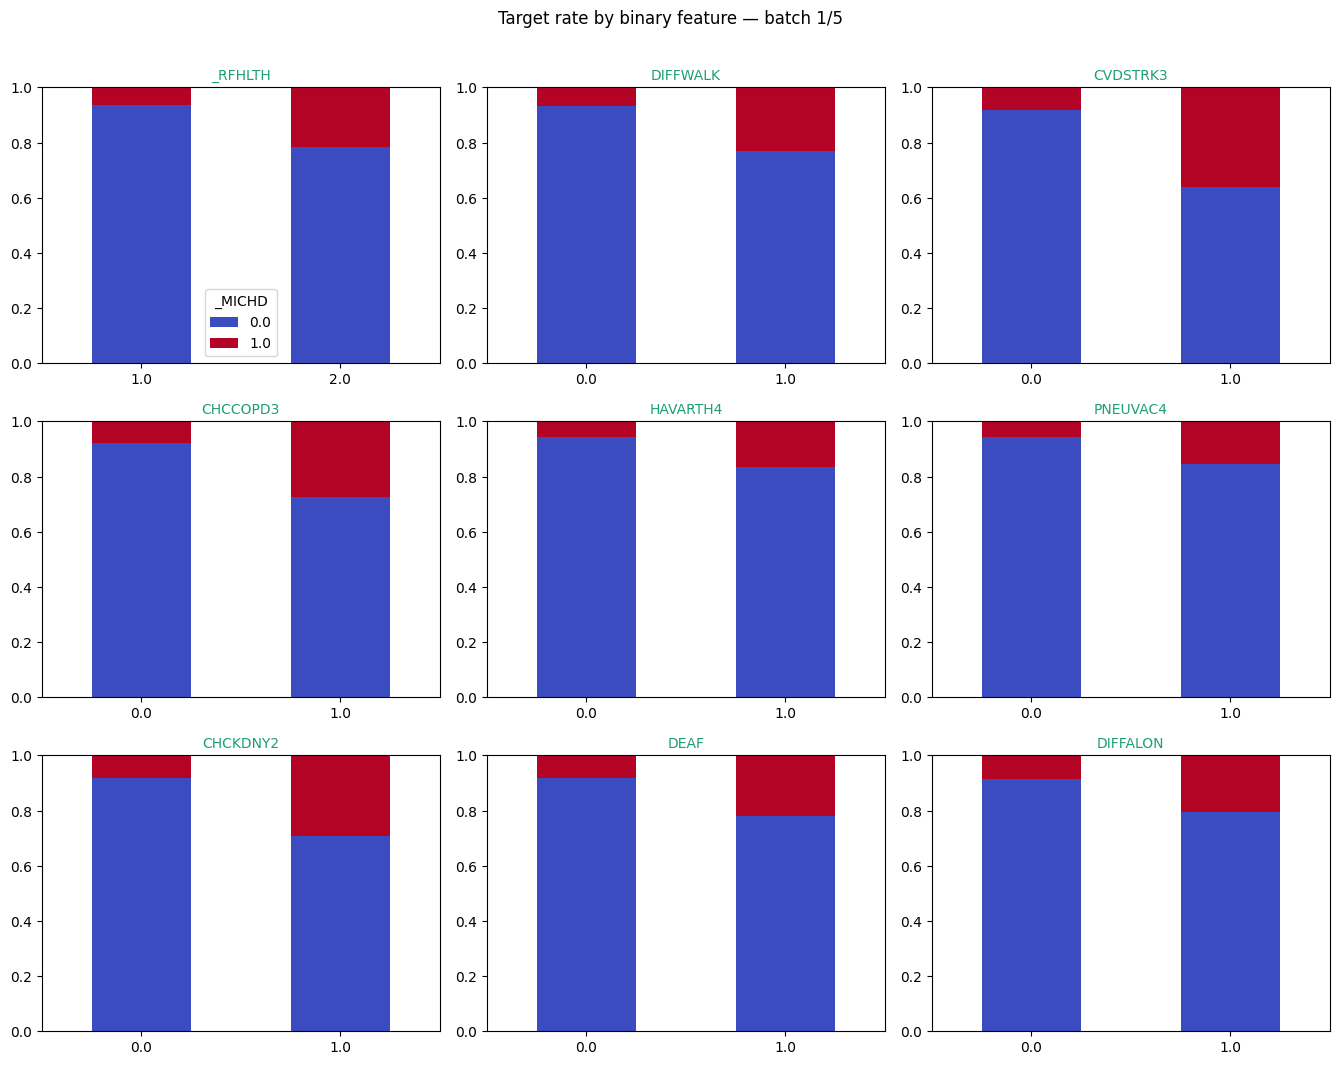

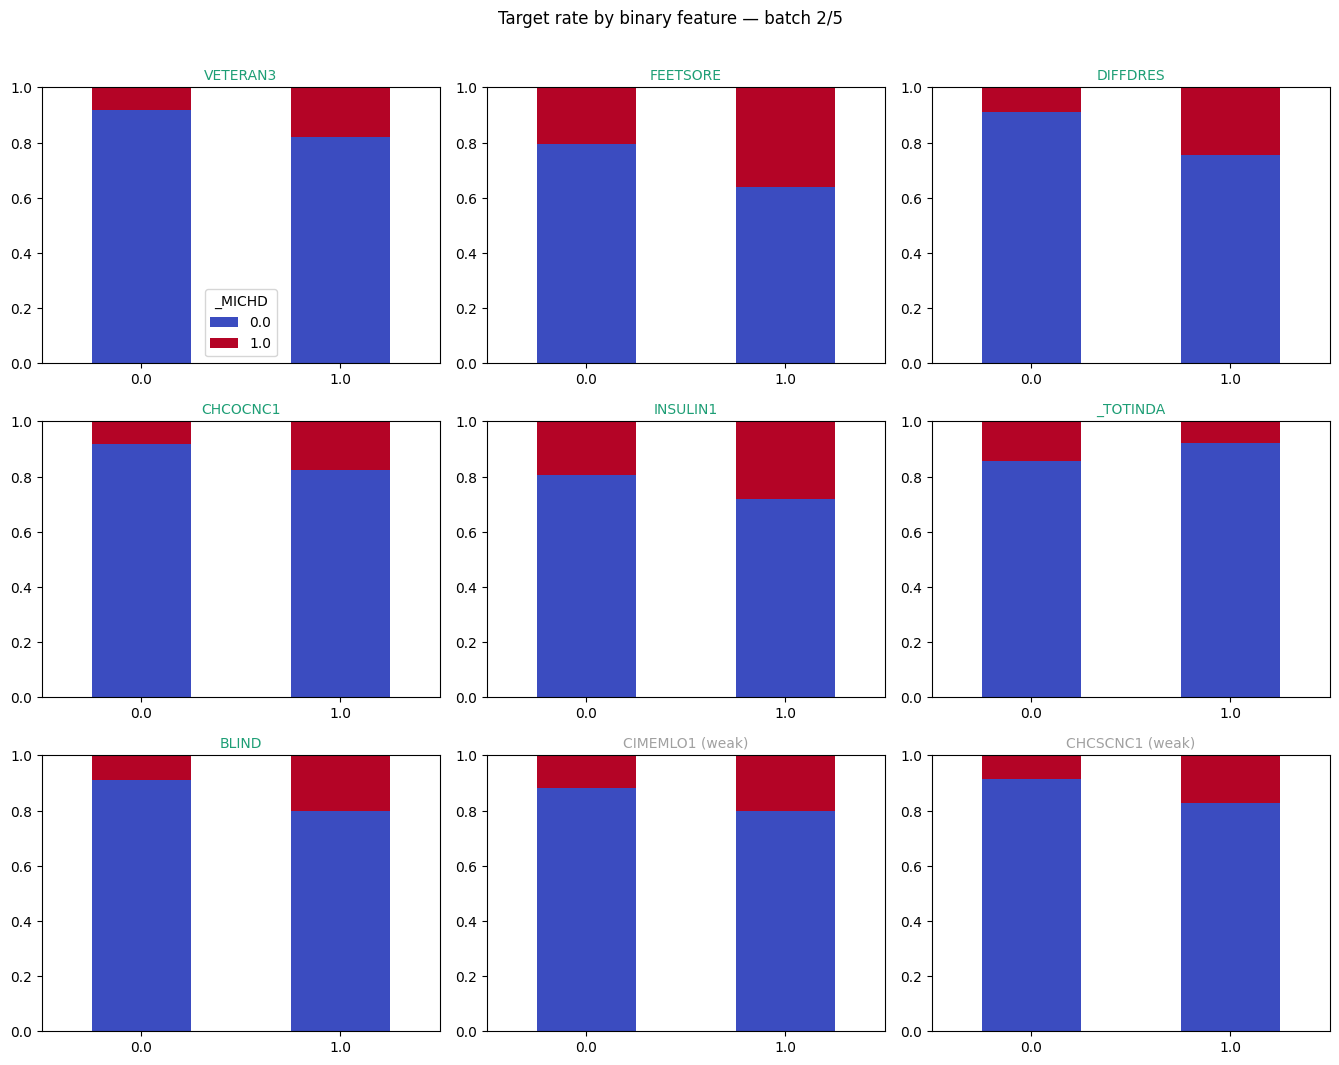

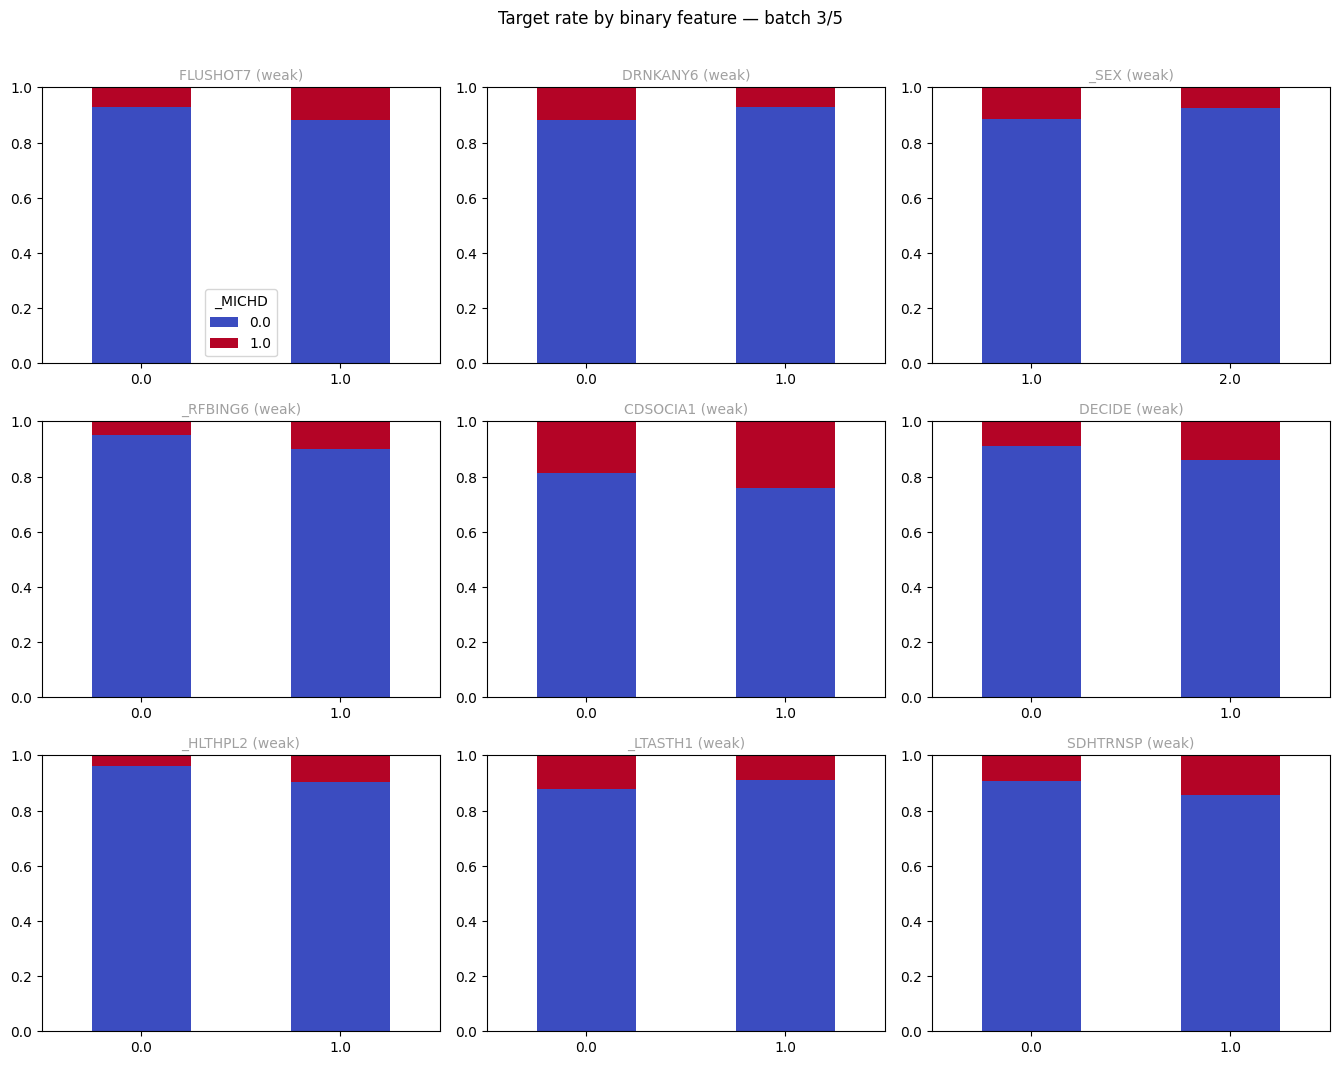

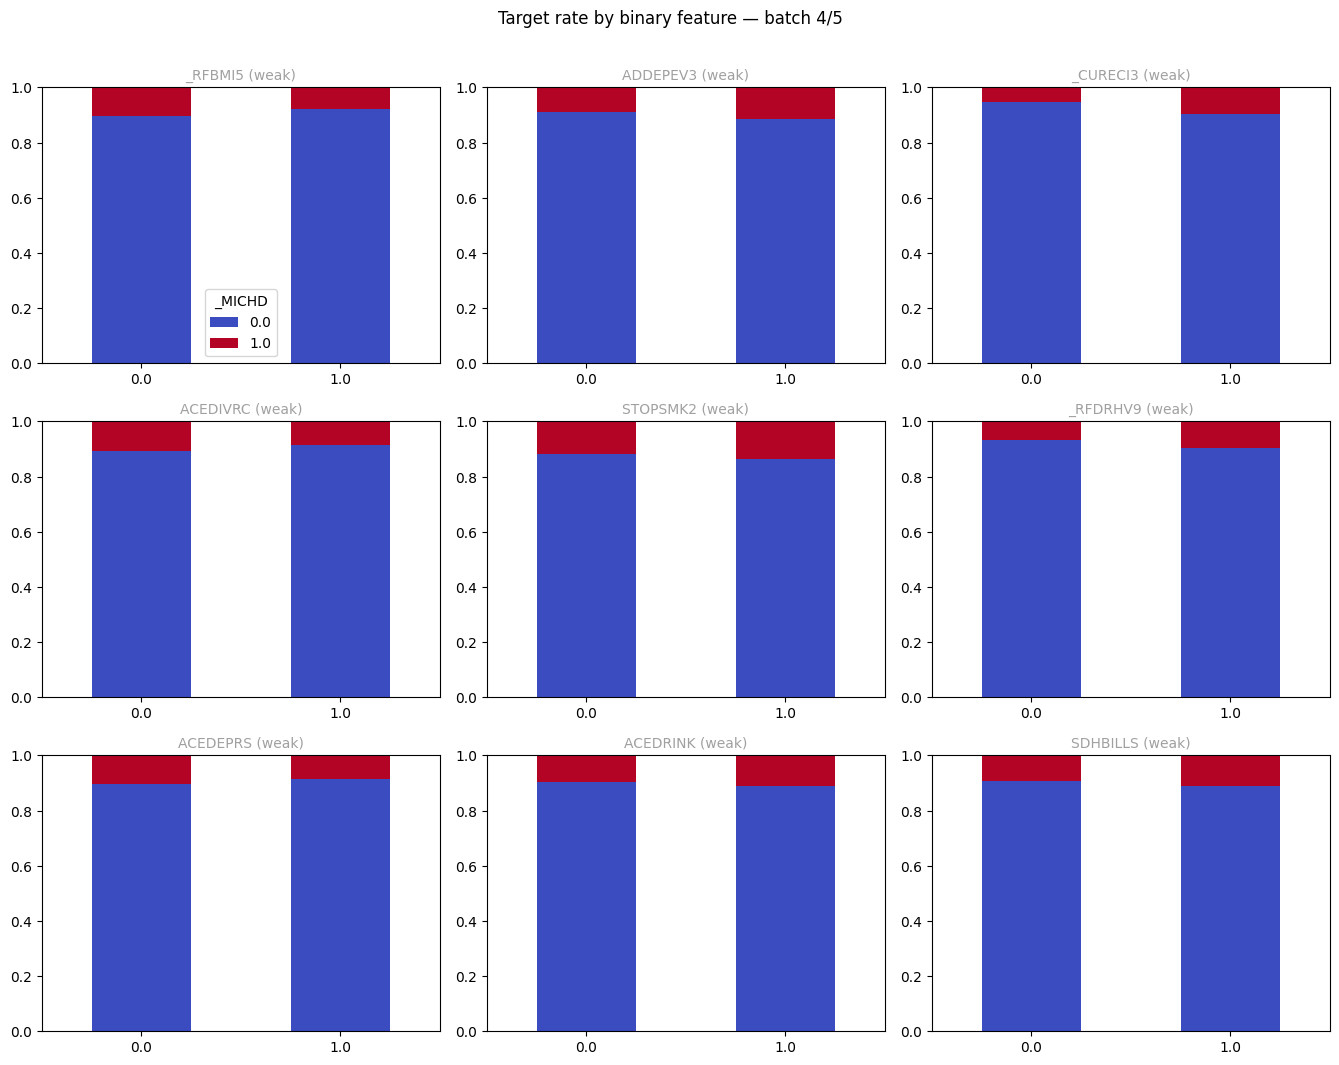

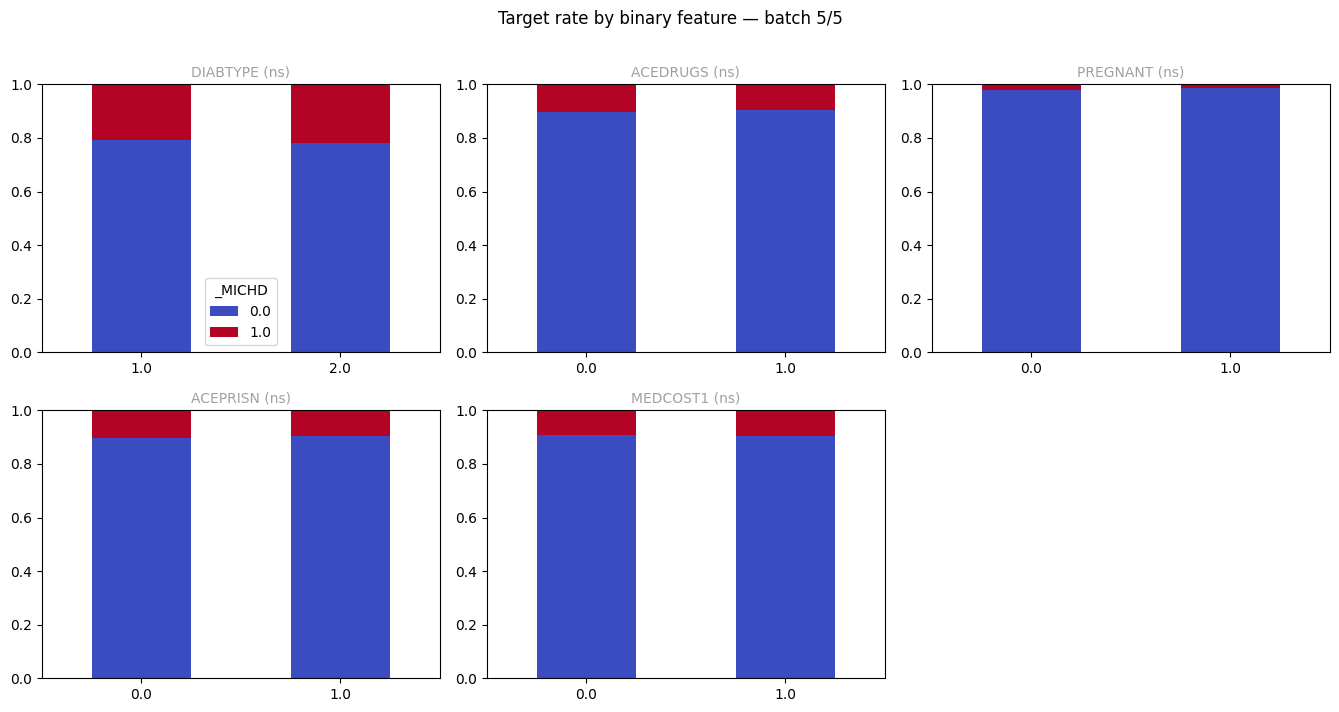

,feature,cramers_v,p_value,sig_p,sig_cv,sig_cat
31,_RFHLTH,0.209497,0.000000e+00,True,True,both
13,DIFFWALK,0.206285,0.000000e+00,True,True,both
1,CVDSTRK3,0.199785,0.000000e+00,True,True,both
4,CHCCOPD3,0.183192,0.000000e+00,True,True,both
7,HAVARTH4,0.177199,0.000000e+00,True,True,both
17,PNEUVAC4,0.165316,0.000000e+00,True,True,both
6,CHCKDNY2,0.158429,0.000000e+00,True,True,both
10,DEAF,0.136338,0.000000e+00,True,True,both
15,DIFFALON,0.110657,0.000000e+00,True,True,both
8,VETERAN3,0.107342,0.000000e+00,True,True,both


In [27]:
# Binary Features

bin_results = []
for col in binary_cols:
    clean = df[[col, TARGET]].dropna()
    ct    = pd.crosstab(clean[col], clean[TARGET])
    chi2, pval, _, _ = chi2_contingency(ct)
    cv    = cramers_v(clean[col], clean[TARGET])
    bin_results.append({"feature": col, "cramers_v": cv, "p_value": pval})

bin_df = pd.DataFrame(bin_results).sort_values("cramers_v", ascending=False)
bin_df["sig_p"]  = bin_df["p_value"]   <= P_THRESHOLD
bin_df["sig_cv"] = bin_df["cramers_v"] >= CV_THRESHOLD

# 4-way classification
def _sig_category(row):
    if row["sig_p"] and row["sig_cv"]:   return "both"
    if row["sig_p"]:                     return "p_only"
    if row["sig_cv"]:                    return "cv_only"
    return "neither"

bin_df["sig_cat"] = bin_df.apply(_sig_category, axis=1)

sig_bin = bin_df[bin_df["sig_cat"] == "both"]["feature"].tolist()
all_bin = bin_df["feature"].tolist()

# colour + label lookup
CAT_COLOR = {
    "both":    "#1D9E75",   # green: strong signal
    "p_only":  "#A8D8C0",   # mint: significant but weak effect
    "cv_only": "#F4A736",   # amber: notable effect, unreliable p
    "neither": "#B0B0B0",   # grey: nothing
}
CAT_LABEL = {
    "both":    f"p <= {P_THRESHOLD} & V >= {CV_THRESHOLD}",
    "p_only":  f"p <= {P_THRESHOLD} only (weak effect)",
    "cv_only": f"V >= {CV_THRESHOLD} only (unreliable p)",
    "neither": "Not significant",
}

# ranking chart
feat_idx = bin_df.set_index("feature")
plot_df  = feat_idx.loc[all_bin, "cramers_v"].sort_values()
colors   = [CAT_COLOR[feat_idx.loc[f, "sig_cat"]] for f in plot_df.index]

fig, ax = plt.subplots(figsize=(8, max(3, len(all_bin) * 0.4 + 1)))
plot_df.plot(kind="barh", ax=ax, color=colors)
ax.axvline(CV_THRESHOLD, color="#F4A736", linewidth=1, linestyle="--", label=f"V = {CV_THRESHOLD}")
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel("Cramér's V")
ax.set_title(f"Binary features — association with {TARGET} "
             f"({len(sig_bin)}/{len(all_bin)} fully significant)")

present_cats = bin_df["sig_cat"].unique()
legend_patches = [Patch(color=CAT_COLOR[c], label=CAT_LABEL[c])
                  for c in ["both", "p_only", "cv_only", "neither"] if c in present_cats]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

# stacked bar grids
CAT_SUFFIX = {"both": "", "p_only": " (weak)", "cv_only": " (p?)", "neither": " (ns)"}

def bin_plot_fn(col, j, ax):
    ct = pd.crosstab(df[col], df[TARGET], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=ax,
            colormap="coolwarm", legend=(j == 0), rot=0)
    cat   = feat_idx.loc[col, "sig_cat"]
    color = CAT_COLOR[cat] if cat == "both" else "#A0A0A0"
    ax.set_title(f"{col}{CAT_SUFFIX[cat]}", fontsize=10, color=color)
    ax.set_ylim(0, 1); ax.set_xlabel("")

plot_chunks(all_bin, bin_plot_fn,
            "Target rate by binary feature — batch {}/{}")

bin_df

### Significance Testing & Effect Size Estimation on Continuous Variables vs\. \_MICHD

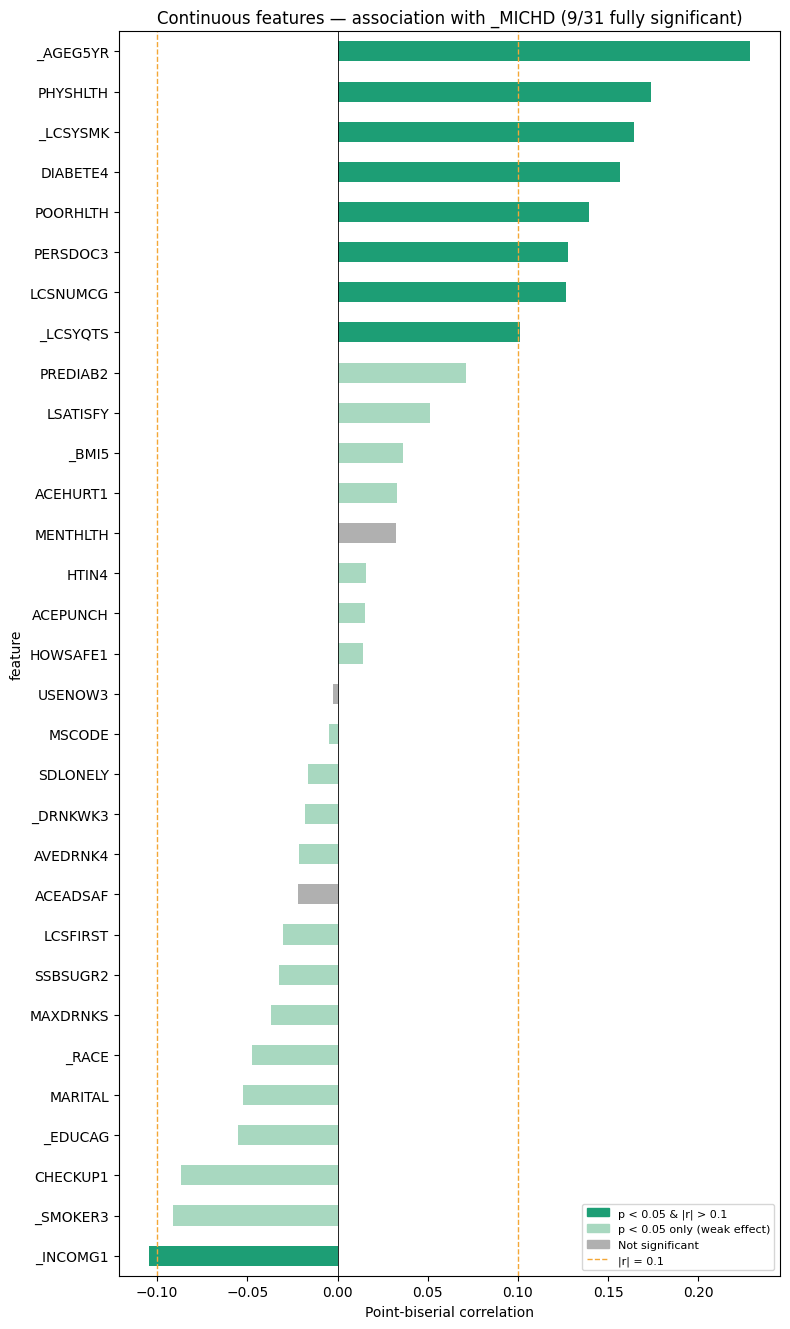

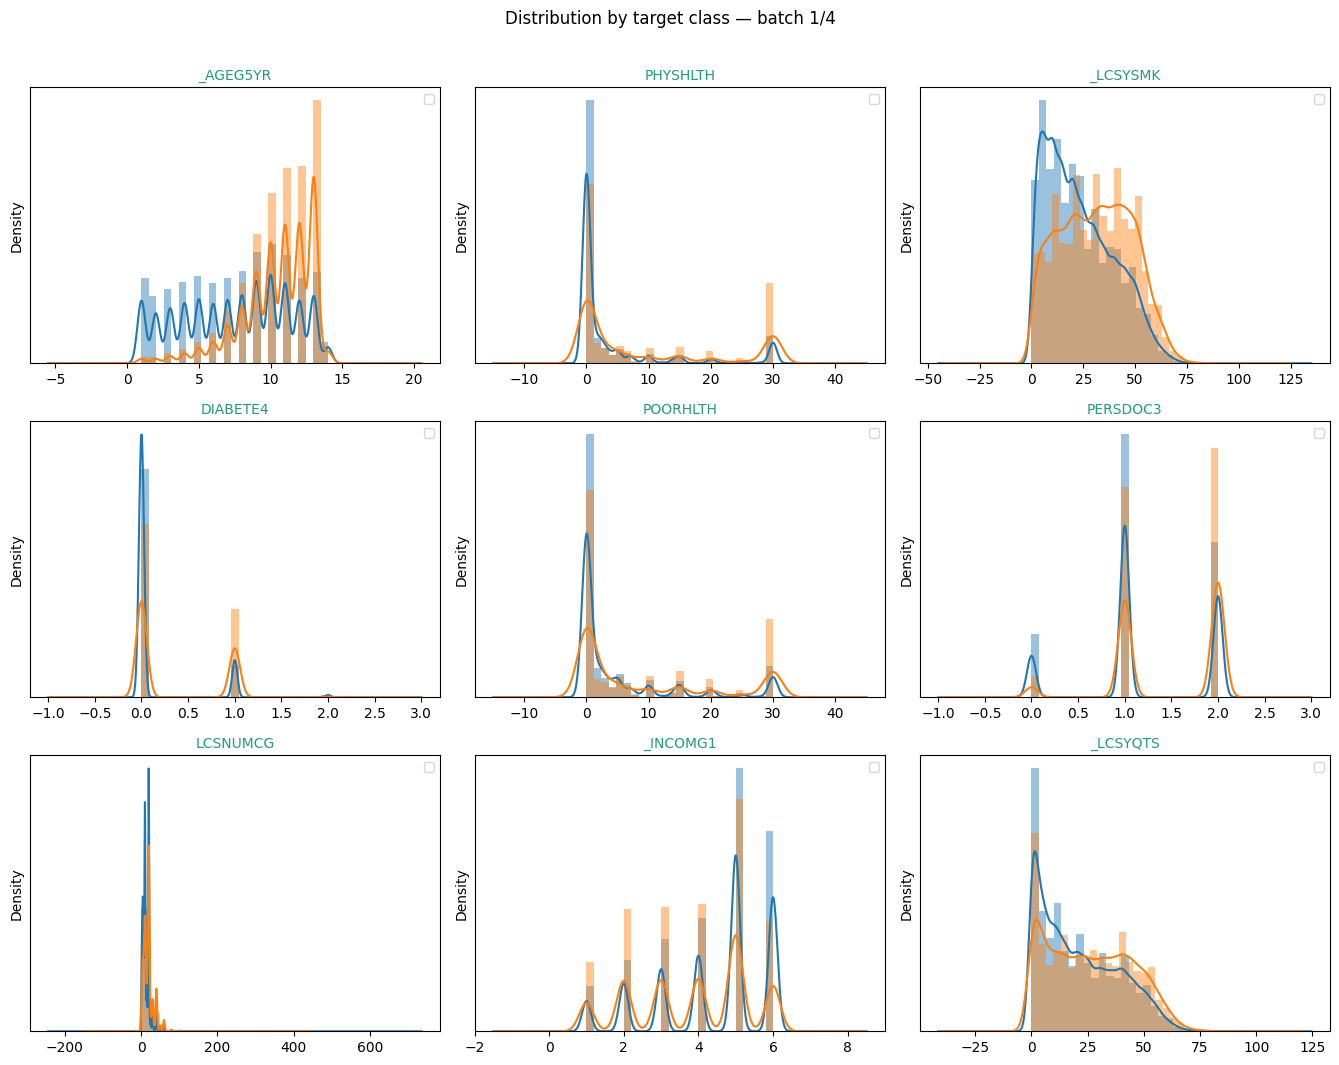

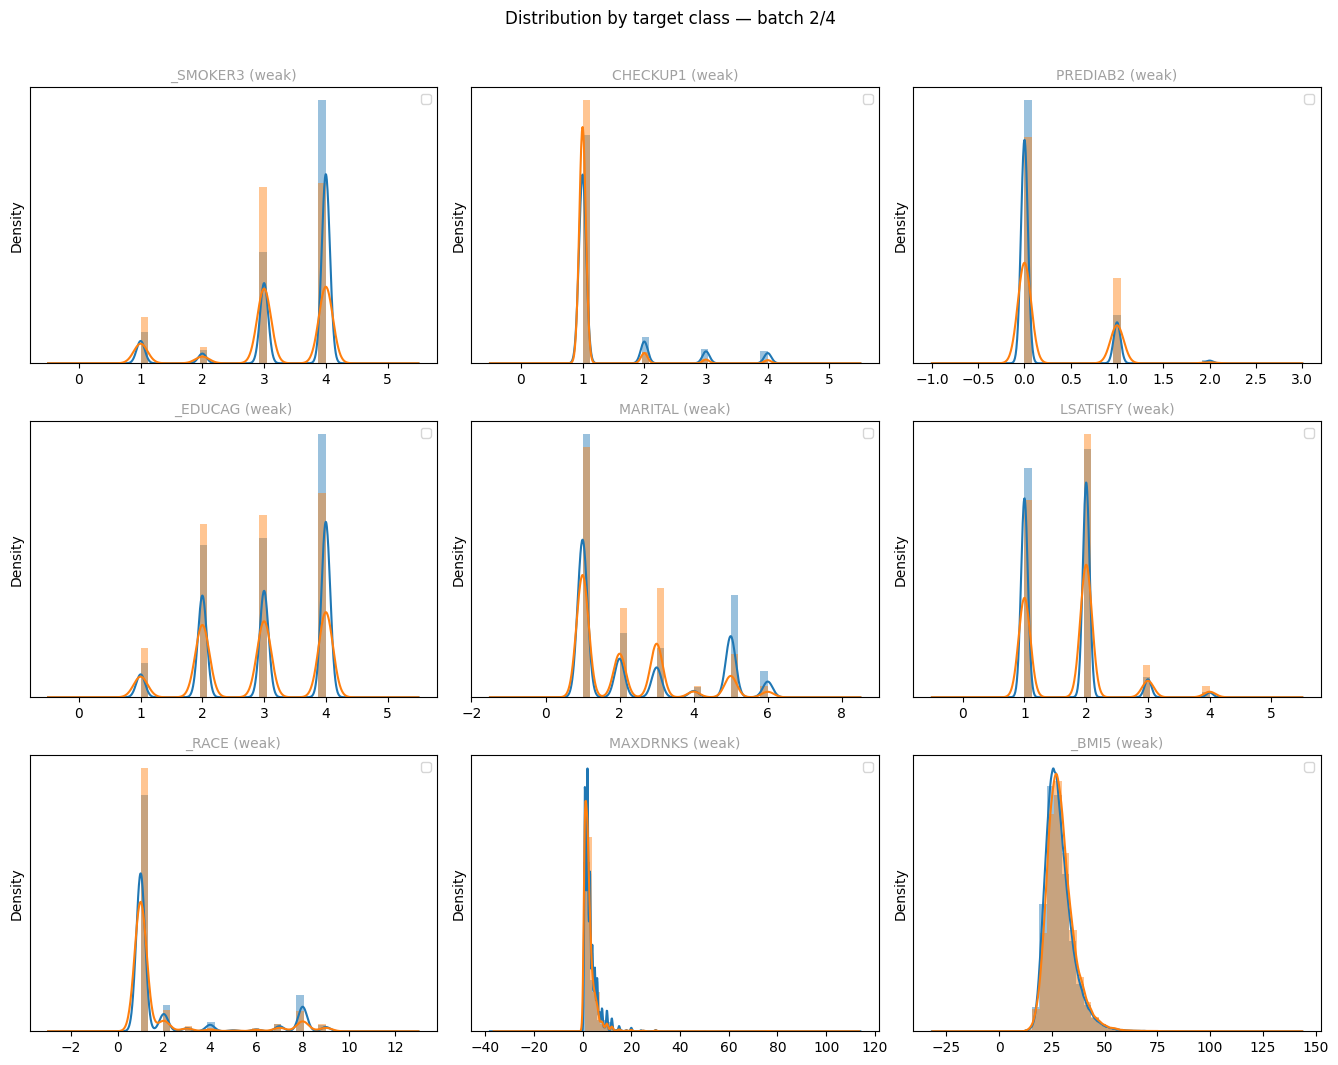

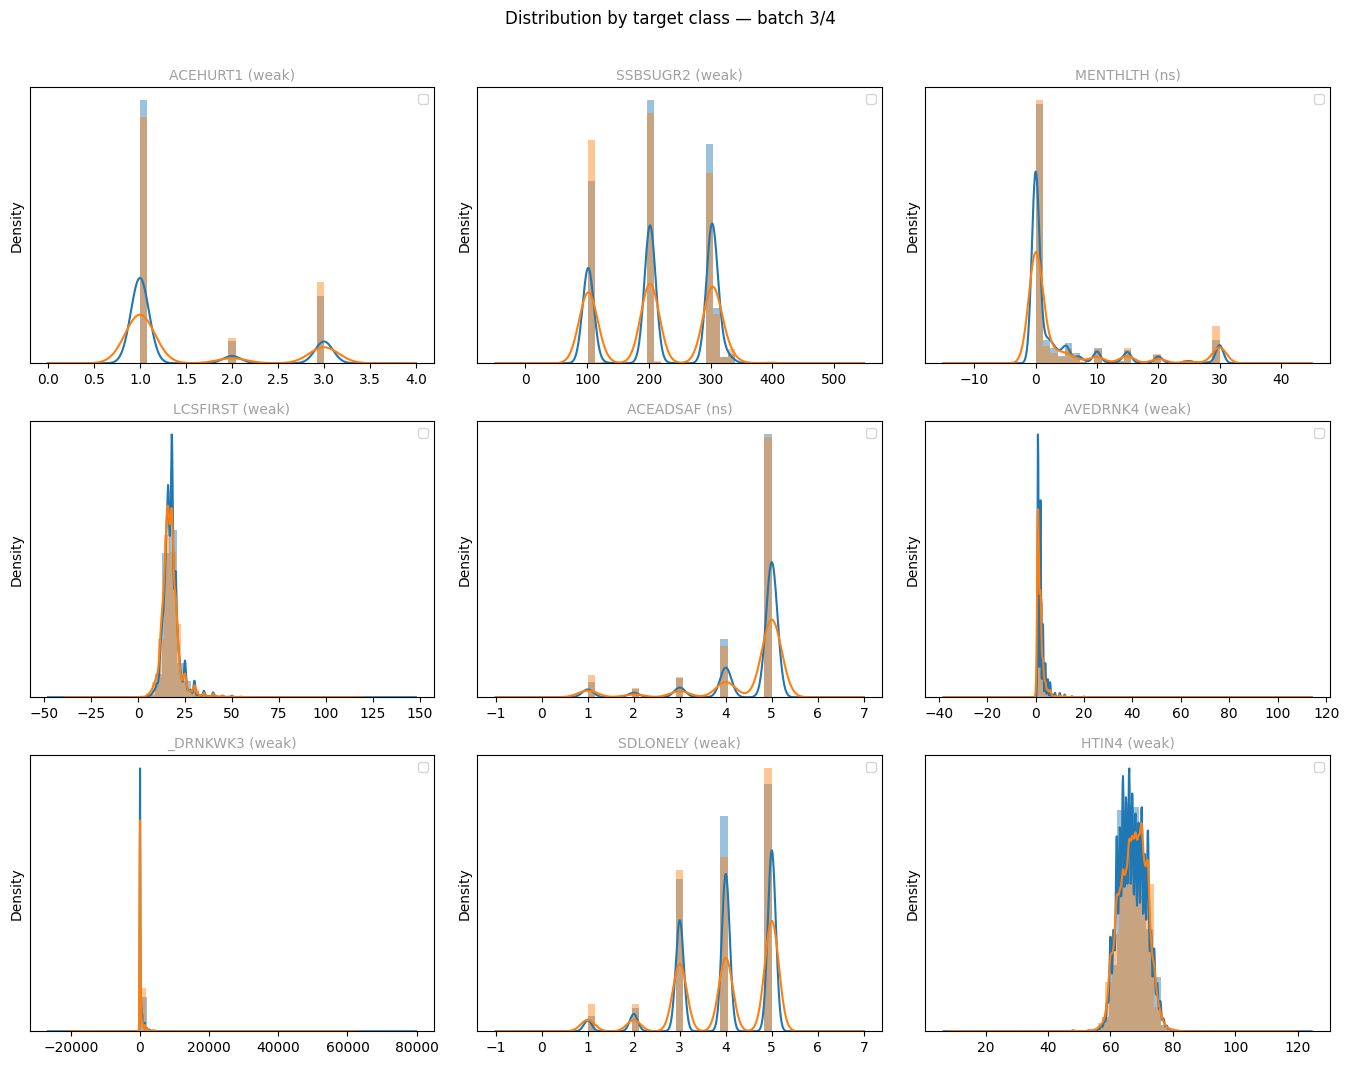

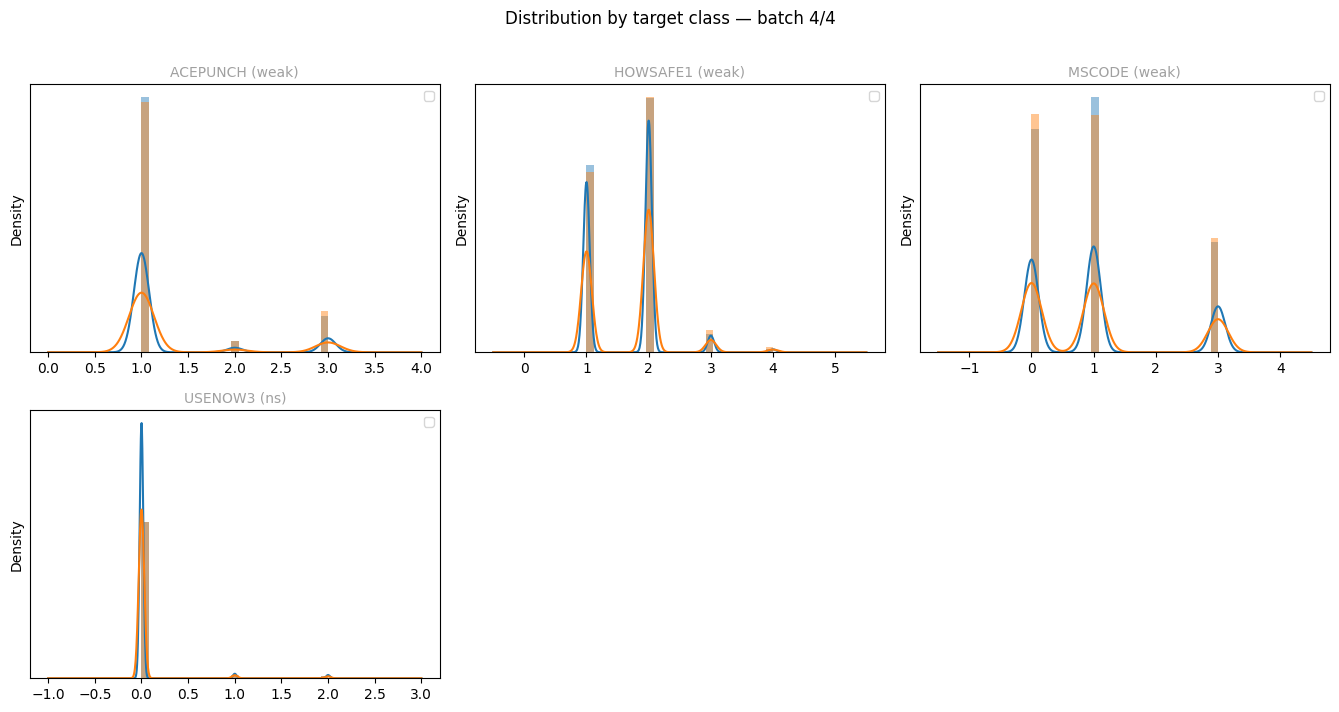

In [29]:
# Continuous Features

cont_results = []
for col in continuous_cols:
    clean = df[[col, TARGET]].dropna()
    corr, _ = pointbiserialr(clean[col], clean[TARGET])
    g0, g1  = clean[clean[TARGET]==0][col], clean[clean[TARGET]==1][col]
    _, pval = mannwhitneyu(g0, g1, alternative="two-sided")
    cont_results.append({"feature": col, "pb_corr": corr,
                         "abs_corr": abs(corr), "p_mw": pval})

cont_df = pd.DataFrame(cont_results).sort_values("abs_corr", ascending=False)
cont_df["sig_p"]  = cont_df["p_mw"]     < P_THRESHOLD
cont_df["sig_cv"] = cont_df["abs_corr"] > CORR_THRESHOLD

cont_df["sig_cat"] = cont_df.apply(_sig_category, axis=1)

sig_cont = cont_df[cont_df["sig_cat"] == "both"]["feature"].tolist()
all_cont = cont_df["feature"].tolist()

CONT_CAT_LABEL = {
    "both":    f"p < {P_THRESHOLD} & |r| > {CORR_THRESHOLD}",
    "p_only":  f"p < {P_THRESHOLD} only (weak effect)",
    "cv_only": f"|r| > {CORR_THRESHOLD} only (unreliable p)",
    "neither": "Not significant",
}

# ranking chart
feat_idx_c = cont_df.set_index("feature")
plot_df_c  = feat_idx_c.loc[all_cont, "pb_corr"].sort_values()
colors_c   = [CAT_COLOR[feat_idx_c.loc[f, "sig_cat"]] for f in plot_df_c.index]

fig, ax = plt.subplots(figsize=(8, max(3, len(all_cont) * 0.4 + 1)))
plot_df_c.plot(kind="barh", ax=ax, color=colors_c)
ax.axvline(0,                color="black",   linewidth=0.6)
ax.axvline( CORR_THRESHOLD,  color="#F4A736", linewidth=1, linestyle="--")
ax.axvline(-CORR_THRESHOLD,  color="#F4A736", linewidth=1, linestyle="--")
ax.set_xlabel("Point-biserial correlation")
ax.set_title(f"Continuous features — association with {TARGET} "
             f"({len(sig_cont)}/{len(all_cont)} fully significant)")

present_cats_c   = cont_df["sig_cat"].unique()
legend_patches_c = [Patch(color=CAT_COLOR[c], label=CONT_CAT_LABEL[c])
                    for c in ["both", "p_only", "cv_only", "neither"] if c in present_cats_c]
legend_patches_c.append(Line2D([0], [0], color="#F4A736", linewidth=1,
                                linestyle="--", label=f"|r| = {CORR_THRESHOLD}"))
ax.legend(handles=legend_patches_c, loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

# KDE overlay grids
classes    = sorted(df[TARGET].unique())
cmap       = plt.colormaps["tab10"]
kde_colors = [cmap(i) for i in range(len(classes))]

def cont_plot_fn(col, j, ax):
    for k, cls in enumerate(classes):
        subset = df[df[TARGET] == cls][col].dropna()
        if len(subset) < 2:
            continue
        ax.hist(subset, bins=25, alpha=0.45, color=kde_colors[k], density=True,
                label="_nolegend_")
        try:
            subset.plot.kde(ax=ax, color=kde_colors[k], linewidth=1.5,
                            label="_nolegend_")
        except Exception:
            pass

    cat   = feat_idx_c.loc[col, "sig_cat"]
    color = CAT_COLOR[cat] if cat == "both" else "#A0A0A0"
    ax.set_title(f"{col}{CAT_SUFFIX[cat]}", fontsize=10, color=color)
    ax.set_yticks([])

    handles = [Patch(color=kde_colors[k], alpha=0.6, label=f"{TARGET}={cls}")
            for k, cls in enumerate(classes)]
    ax.legend(handles=[h for h in handles if not h.get_label().startswith("_")], fontsize=9)

plot_chunks(all_cont, cont_plot_fn,
            "Distribution by target class — batch {}/{}")

In [31]:
cont_df

,feature,pb_corr,abs_corr,p_mw,sig_p,sig_cv,sig_cat
22,_AGEG5YR,0.228582,0.228582,0.000000e+00,True,True,both
0,PHYSHLTH,0.173661,0.173661,0.000000e+00,True,True,both
28,_LCSYSMK,0.164334,0.164334,0.000000e+00,True,True,both
5,DIABETE4,0.156390,0.156390,0.000000e+00,True,True,both
2,POORHLTH,0.139270,0.139270,0.000000e+00,True,True,both
3,PERSDOC3,0.127502,0.127502,0.000000e+00,True,True,both
9,LCSNUMCG,0.126650,0.126650,0.000000e+00,True,True,both
26,_INCOMG1,-0.104638,0.104638,0.000000e+00,True,True,both
29,_LCSYQTS,0.100909,0.100909,2.169102e-239,True,True,both
27,_SMOKER3,-0.091132,0.091132,0.000000e+00,True,False,p_only


### Summary, Final Selection of Features based on Significance and Effect Size

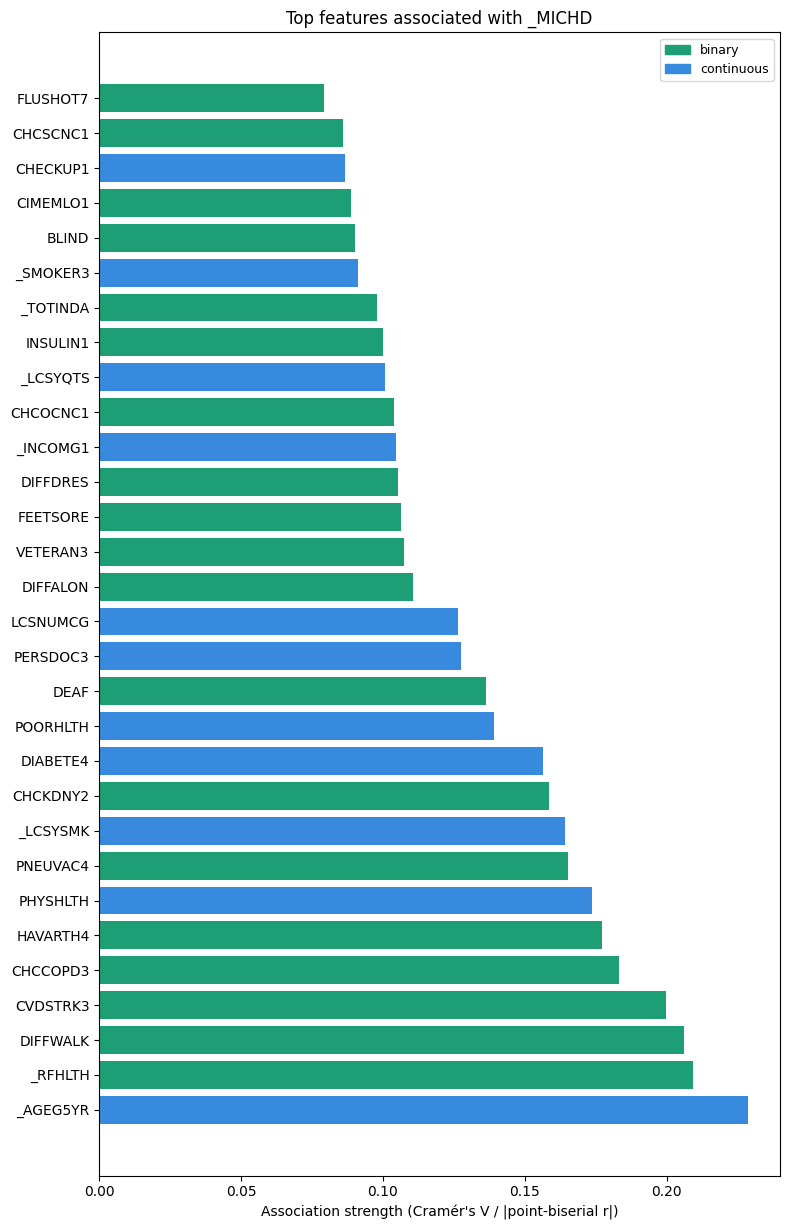

,feature,score,p_val,type
22,_AGEG5YR,0.228582,0.000000e+00,continuous
31,_RFHLTH,0.209497,0.000000e+00,binary
13,DIFFWALK,0.206285,0.000000e+00,binary
1,CVDSTRK3,0.199785,0.000000e+00,binary
4,CHCCOPD3,0.183192,0.000000e+00,binary
7,HAVARTH4,0.177199,0.000000e+00,binary
0,PHYSHLTH,0.173661,0.000000e+00,continuous
17,PNEUVAC4,0.165316,0.000000e+00,binary
28,_LCSYSMK,0.164334,0.000000e+00,continuous
6,CHCKDNY2,0.158429,0.000000e+00,binary


In [33]:
# Summary
bin_top = (bin_df[bin_df["sig_cat"].isin(["both", "p_only"])]
           [["feature", "cramers_v", "p_value"]]
           .rename(columns={"cramers_v": "score", "p_value": "p_val"})
           .assign(type="binary"))

cont_top = (cont_df[cont_df["sig_cat"].isin(["both", "p_only"])]
            [["feature", "abs_corr", "p_mw"]]
            .rename(columns={"abs_corr": "score", "p_mw": "p_val"})
            .assign(type="continuous"))

summary = (pd.concat([bin_top, cont_top])
           .sort_values("score", ascending=False)
           .head(30))

colors_map = {"binary": "#1D9E75", "continuous": "#378ADD"}
bar_colors = summary["type"].map(colors_map)

fig, ax = plt.subplots(figsize=(8, len(summary) * 0.38 + 1))
ax.barh(summary["feature"], summary["score"], color=bar_colors)
ax.set_xlabel("Association strength (Cramér's V / |point-biserial r|)")
ax.set_title(f"Top features associated with {TARGET}")
ax.legend(handles=[Patch(color=v, label=k) for k, v in colors_map.items()], fontsize=9)
plt.tight_layout(); plt.show()

summary

### Correlation Matrix on the Final Column List to Spot Multicollinearity

/root/venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/root/venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
High-correlation pairs (>0.7):


,feature_a,feature_b,metric,value,p_value


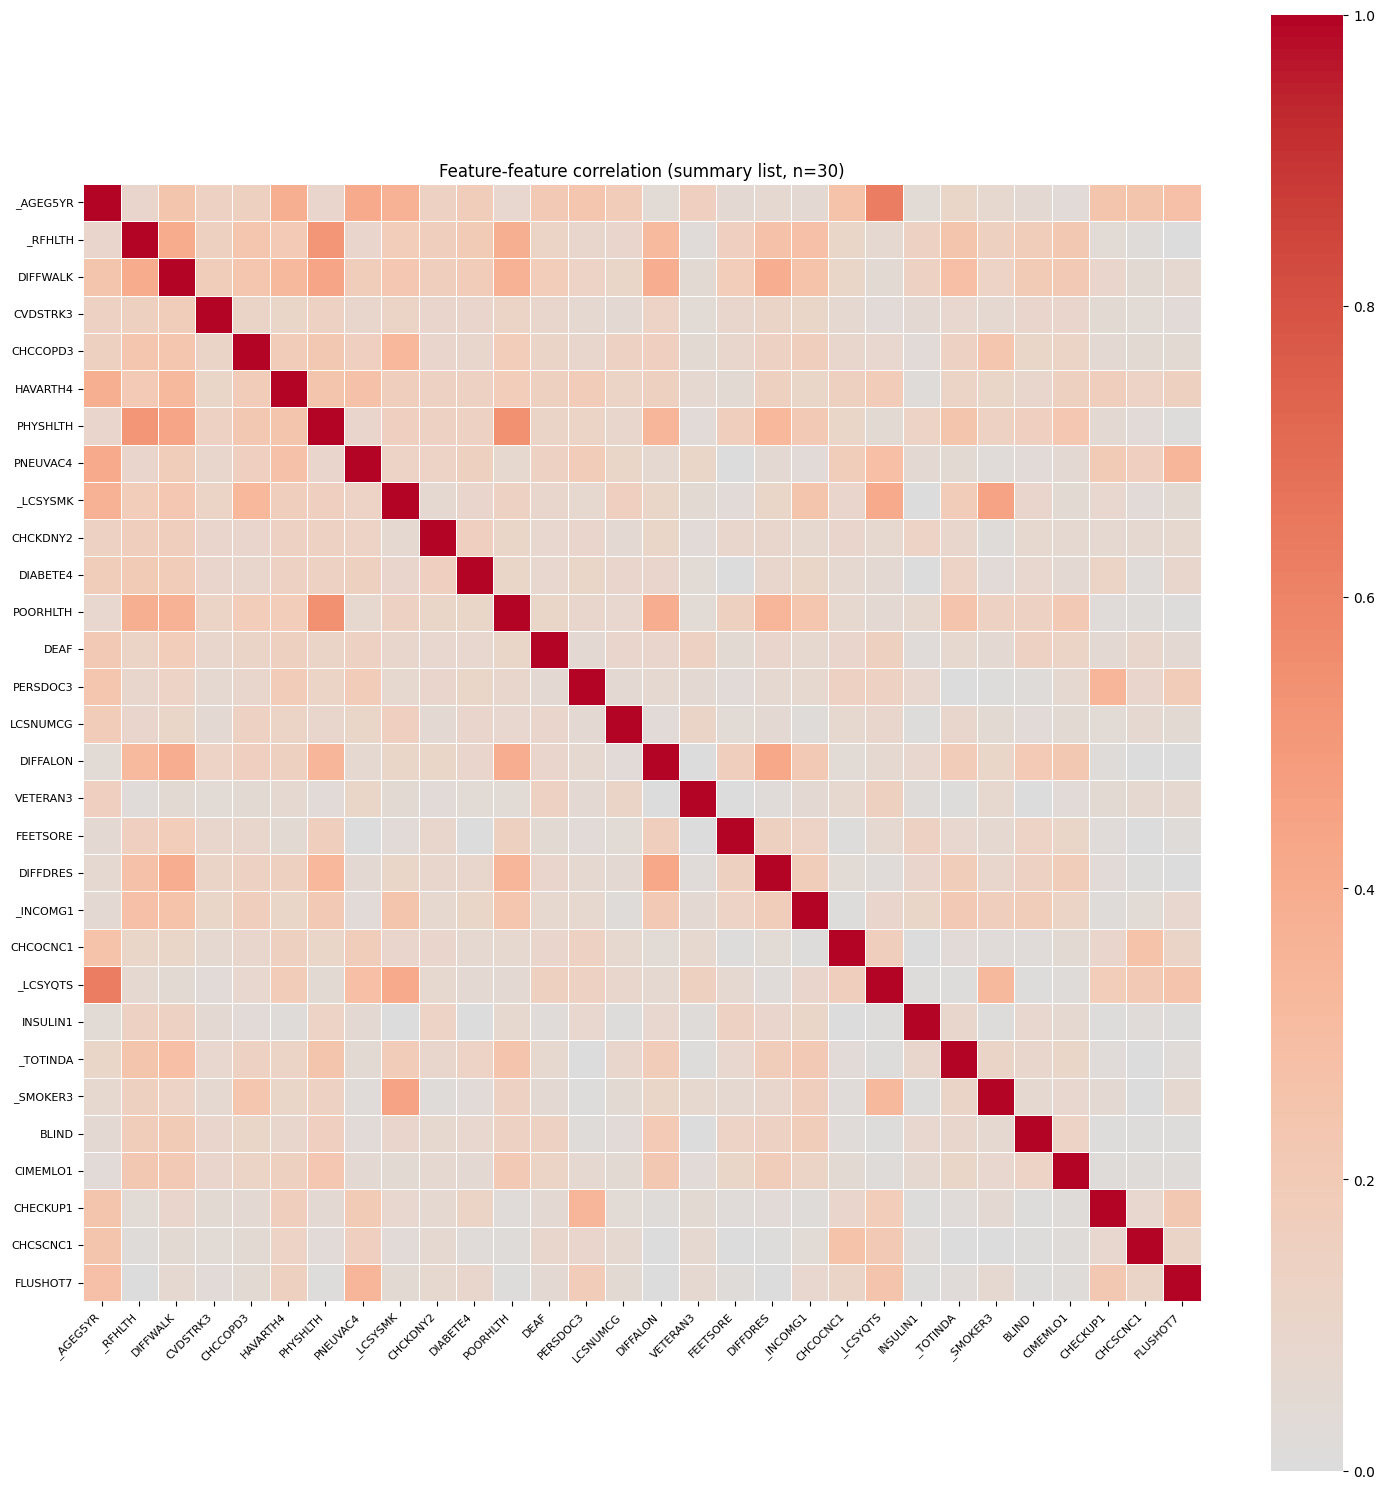

In [35]:
# Feature-feature correlation within summary list
summary_features = summary["feature"].tolist()
summary_bin  = [f for f in summary_features if f in binary_cols]
summary_cont = [f for f in summary_features if f in continuous_cols]

# binary-binary: Cramer's V
bin_corr_results = []
for i, a in enumerate(summary_bin):
    for b in summary_bin[i+1:]:
        clean = df[[a, b]].dropna()
        ct    = pd.crosstab(clean[a], clean[b])
        cv    = cramers_v(clean[a], clean[b])
        _, pval, _, _ = chi2_contingency(ct)
        bin_corr_results.append({"feature_a": a, "feature_b": b,
                                  "metric": "cramers_v", "value": cv, "p_value": pval})

# continuous-continuous: Pearson r
cont_corr_results = []
for i, a in enumerate(summary_cont):
    for b in summary_cont[i+1:]:
        clean = df[[a, b]].dropna()
        r, pval = pearsonr(clean[a], clean[b])
        cont_corr_results.append({"feature_a": a, "feature_b": b,
                                   "metric": "pearson_r", "value": abs(r), "p_value": pval})

# binary-continuous: point-biserial
mixed_corr_results = []
for a in summary_bin:
    for b in summary_cont:
        clean = df[[a, b]].dropna()
        r, pval = pointbiserialr(clean[a], clean[b])
        mixed_corr_results.append({"feature_a": a, "feature_b": b,
                                    "metric": "point_biserial", "value": abs(r), "p_value": pval})

pair_df = (pd.concat([pd.DataFrame(r) for r in
                      [bin_corr_results, cont_corr_results, mixed_corr_results]
                      if r])
           .sort_values("value", ascending=False)
           .reset_index(drop=True))

# flag high correlation
PAIR_THRESHOLD = 0.7
pair_df["high_corr"] = pair_df["value"] > PAIR_THRESHOLD

print(f"High-correlation pairs (>{PAIR_THRESHOLD}):")
display(pair_df[pair_df["high_corr"]][["feature_a", "feature_b", "metric", "value", "p_value"]])

# heatmap across all summary features
corr_matrix = pd.DataFrame(index=summary_features, columns=summary_features, dtype=float)
np.fill_diagonal(corr_matrix.values, 1.0)

for _, row in pair_df.iterrows():
    corr_matrix.loc[row["feature_a"], row["feature_b"]] = row["value"]
    corr_matrix.loc[row["feature_b"], row["feature_a"]] = row["value"]

corr_matrix = corr_matrix.fillna(0)

fig, ax = plt.subplots(figsize=(max(8, len(summary_features) * 0.5),
                                max(6, len(summary_features) * 0.5)))
sns.heatmap(corr_matrix.astype(float), ax=ax, cmap="coolwarm", center=0,
            vmin=0, vmax=1, annot=len(summary_features) <= 20,
            fmt=".2f", linewidths=0.5, square=True,
            xticklabels=True, yticklabels=True)
ax.set_title(f"Feature-feature correlation (summary list, n={len(summary_features)})")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout(); plt.show()

### No significant multicollinearity detected in the final selection of features\. Below is the final selection\.

In [37]:
selected_features = summary['feature']
selected_features

22    _AGEG5YR
31     _RFHLTH
13    DIFFWALK
1     CVDSTRK3
4     CHCCOPD3
7     HAVARTH4
0     PHYSHLTH
17    PNEUVAC4
28    _LCSYSMK
6     CHCKDNY2
5     DIABETE4
2     POORHLTH
10        DEAF
3     PERSDOC3
9     LCSNUMCG
15    DIFFALON
8     VETERAN3
20    FEETSORE
14    DIFFDRES
26    _INCOMG1
3     CHCOCNC1
29    _LCSYQTS
19    INSULIN1
33    _TOTINDA
27    _SMOKER3
11       BLIND
21    CIMEMLO1
4     CHECKUP1
2     CHCSCNC1
16    FLUSHOT7
Name: feature, dtype: object

In [51]:
with open("selected_features.pkl", "wb") as f:
    pickle.dump(selected_features, f)

# Quick Random Forest to Evaluate if it Works

In [1]:
%pip install scikit-learn==1.5.2 imbalanced-learn==0.12.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 35.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.2
    Uninstalling scikit-learn-1.3.2:
      Successfully uninstalled scikit-learn-1.3.2

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# imports
from sklearn.ensemble         import RandomForestClassifier
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      roc_auc_score, roc_curve,
                                      precision_recall_curve, average_precision_score)
from sklearn.preprocessing    import StandardScaler
from sklearn.impute            import SimpleImputer
from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from imblearn.under_sampling   import RandomUnderSampler
import matplotlib.gridspec as gridspec

Before resampling — 0: 328,101  |  1: 33,870
After resampling  — 0: 33,870  |  1: 33,870
Test (untouched)  — 0: 82,025  |  1: 8,468

CV AUC (5-fold): 0.8307 ± 0.0036

Test AUC:           0.8321
Test Avg Precision: 0.3476

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.70      0.82     82025
         1.0       0.22      0.81      0.35      8468

    accuracy                           0.71     90493
   macro avg       0.60      0.76      0.58     90493
weighted avg       0.90      0.71      0.77     90493

/tmp/ipykernel_106/1675703084.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


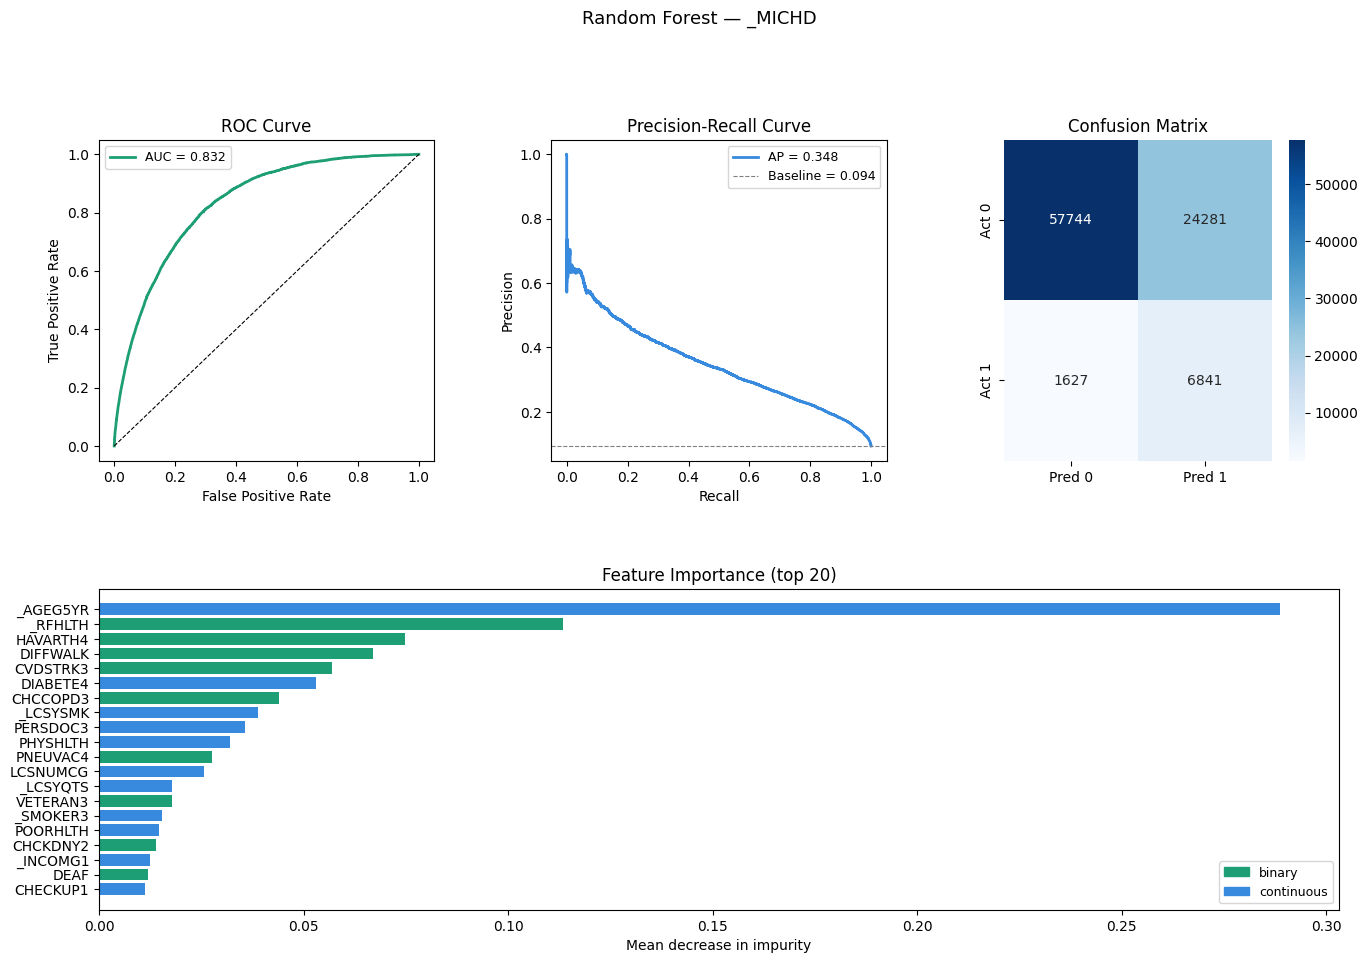

In [34]:
# config
FEATURES     = summary["feature"].tolist()
TEST_SIZE    = 0.2
RANDOM_STATE = 42
CV_FOLDS     = 5

RF_PARAMS = {
    "n_estimators":    300,
    "max_depth":       None,
    "min_samples_leaf": 20,
    "random_state":    RANDOM_STATE,
    "n_jobs":          -1,
}

df = df[df[TARGET].notna()]

# data prep
model_df = df[FEATURES + [TARGET]].copy()
X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

# undersample majority class on train only
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

print(f"Before resampling — 0: {(y_train==0).sum():,}  |  1: {(y_train==1).sum():,}")
print(f"After resampling  — 0: {(y_train_res==0).sum():,}  |  1: {(y_train_res==1).sum():,}")
print(f"Test (untouched)  — 0: {(y_test==0).sum():,}  |  1: {(y_test==1).sum():,}")

# preprocessing pipeline
bin_features  = [f for f in FEATURES if f in binary_cols]
cont_features = [f for f in FEATURES if f in continuous_cols]

bin_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

cont_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("binary",     bin_transformer,  bin_features),
    ("continuous", cont_transformer, cont_features),
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",        RandomForestClassifier(**RF_PARAMS)),
])

# fit
pipeline.fit(X_train_res, y_train_res)

# cross-validated AUC (on resampled train)
cv_auc = cross_val_score(pipeline, X_train_res, y_train_res,
                          cv=StratifiedKFold(CV_FOLDS, shuffle=True,
                                             random_state=RANDOM_STATE),
                          scoring="roc_auc", n_jobs=-1)
print(f"\nCV AUC ({CV_FOLDS}-fold): {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

# test set evaluation
y_pred   = pipeline.predict(X_test)
y_prob   = pipeline.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_prob)
test_ap  = average_precision_score(y_test, y_prob)

print(f"\nTest AUC:           {test_auc:.4f}")
print(f"Test Avg Precision: {test_ap:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

# plots
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ROC curve
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr, tpr, color="#1D9E75", lw=2, label=f"AUC = {test_auc:.3f}")
ax1.plot([0,1], [0,1], "k--", lw=0.8)
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve"); ax1.legend(fontsize=9)

# Precision-Recall curve
ax2 = fig.add_subplot(gs[0, 1])
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ax2.plot(rec, prec, color="#378ADD", lw=2, label=f"AP = {test_ap:.3f}")
ax2.axhline(y_test.mean(), color="grey", linestyle="--", lw=0.8,
            label=f"Baseline = {y_test.mean():.3f}")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve"); ax2.legend(fontsize=9)

# Confusion matrix
ax3 = fig.add_subplot(gs[0, 2])
cm  = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax3,
            xticklabels=[f"Pred {c}" for c in [0,1]],
            yticklabels=[f"Act {c}"  for c in [0,1]])
ax3.set_title("Confusion Matrix")

# Feature importance (top 20)
ax4 = fig.add_subplot(gs[1, :])
rf_model   = pipeline.named_steps["model"]
imp_df = (pd.DataFrame({"feature": bin_features + cont_features,
                         "importance": rf_model.feature_importances_})
          .sort_values("importance", ascending=False)
          .head(20))
imp_colors = ["#1D9E75" if f in bin_features else "#378ADD" for f in imp_df["feature"]]
ax4.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color=imp_colors[::-1])
ax4.set_xlabel("Mean decrease in impurity")
ax4.set_title("Feature Importance (top 20)")
ax4.legend(handles=[Patch(color="#1D9E75", label="binary"),
                    Patch(color="#378ADD", label="continuous")], fontsize=9)

plt.suptitle(f"Random Forest — {TARGET}", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=88479c56-07bc-4e04-92b4-d8345dc226f4' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>